## E-commerce Website User Logs Analysis
The objective of this project is to analyze customer behavior and identify the key factors affecting sales and returned amounts. Through exploratory data analysis and feature engineering, we aim to uncover patterns that can help improve business performance and reduce return rates.

In [1]:
# The normal imports
import numpy as np
from numpy.random import randn
import pandas as pd

# Import the stats librayr from numpy
from scipy import stats

# These are the plotting modules adn libraries we'll use
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

# Command so that plots appear in the ipython Notebook
%matplotlib inline

In [2]:
# read cleaned data
df = pd.read_csv('Cleaned_Data.csv')
df.head()

,accessed_date,duration_(secs),network_protocol,ip,bytes,accessed_Ffom,age,gender,country,membership,language,sales,returned,returned_amount,pay_method
0,2017-03-14 17:43:57.172,2533,TCP,1.10.195.126,4651,Chrome,28,Female,CA,Normal,English,261.9600,No,0.0,Credit Card
1,2017-03-14 17:43:57.172,4034,TCP,1.1.217.211,4651,Mozilla Firefox,21,Male,AR,Normal,English,731.9400,No,0.0,Debit Card
2,2017-03-14 17:43:26.135,1525,TCP,1.115.198.107,4651,Mozilla Firefox,20,Male,PL,Normal,English,14.6200,No,0.0,Cash
3,2017-03-14 17:43:26.135,4572,TCP,1.121.152.143,4651,Mozilla Firefox,66,Female,IN,Normal,Spanish,957.5775,No,0.0,Credit Card
4,2017-03-14 18:17:09.005,3652,TCP,1.123.135.213,4651,Mozilla Firefox,53,Female,KR,Normal,Spanish,22.3680,No,0.0,Cash


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 172838 entries, 0 to 172837
Data columns (total 15 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   accessed_date     172838 non-null  str    
 1   duration_(secs)   172838 non-null  int64  
 2   network_protocol  172838 non-null  str    
 3   ip                172838 non-null  str    
 4   bytes             172838 non-null  int64  
 5   accessed_Ffom     172838 non-null  str    
 6   age               172838 non-null  int64  
 7   gender            172838 non-null  str    
 8   country           172838 non-null  str    
 9   membership        172838 non-null  str    
 10  language          172838 non-null  str    
 11  sales             172838 non-null  float64
 12  returned          172838 non-null  str    
 13  returned_amount   172838 non-null  float64
 14  pay_method        172838 non-null  str    
dtypes: float64(2), int64(3), str(10)
memory usage: 19.8 MB


In [4]:
df.describe()

,duration_(secs),bytes,age,sales,returned_amount
count,172838.000000,172838.000000,172838.000000,172838.000000,172838.000000
mean,3248.031827,1385.587828,43.214808,381.427171,53.210506
std,1010.872270,1366.733572,10.489798,650.076532,212.583083
min,1500.000000,40.000000,18.000000,0.000000,0.000000
25%,2371.000000,264.000000,43.000000,5.230000,0.000000
50%,3246.000000,589.000000,43.000000,46.920000,0.000000
75%,4124.000000,2430.000000,43.000000,600.160000,0.000000
max,5000.000000,4651.000000,69.000000,2563.056000,1140.304000


#### Feature Engineering to accessed_date convert the DateTime to useful Features Because sales might increase at a specific time or in a specific month and Adding a feature to determine whether the return was successful or not as a boolian

In [5]:
x = []
for i in df['returned']:
    if i == 'Yes' :
        x.append(1)
    else :
         x.append(0)
df['return_yes'] = x


In [6]:
df['accessed_date'] = pd.to_datetime(df['accessed_date'])
df['hour'] = df['accessed_date'].dt.hour
df['day'] = df['accessed_date'].dt.day
df['month'] = df['accessed_date'].dt.month
df['year'] = df['accessed_date'].dt.year
df

,accessed_date,duration_(secs),network_protocol,ip,bytes,accessed_Ffom,age,gender,country,membership,language,sales,returned,returned_amount,pay_method,return_yes,hour,day,month,year
0,2017-03-14 17:43:57.172,2533,TCP,1.10.195.126,4651,Chrome,28,Female,CA,Normal,English,261.9600,No,0.00,Credit Card,0,17,14,3,2017
1,2017-03-14 17:43:57.172,4034,TCP,1.1.217.211,4651,Mozilla Firefox,21,Male,AR,Normal,English,731.9400,No,0.00,Debit Card,0,17,14,3,2017
2,2017-03-14 17:43:26.135,1525,TCP,1.115.198.107,4651,Mozilla Firefox,20,Male,PL,Normal,English,14.6200,No,0.00,Cash,0,17,14,3,2017
3,2017-03-14 17:43:26.135,4572,TCP,1.121.152.143,4651,Mozilla Firefox,66,Female,IN,Normal,Spanish,957.5775,No,0.00,Credit Card,0,17,14,3,2017
4,2017-03-14 18:17:09.005,3652,TCP,1.123.135.213,4651,Mozilla Firefox,53,Female,KR,Normal,Spanish,22.3680,No,0.00,Cash,0,18,14,3,2017
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
172833,2017-03-16 11:42:01.298,4372,TCP,94.197.121.229,4651,Android App,43,Male,US,Normal,English,0.0000,Yes,143.36,Debit Card,1,11,16,3,2017
172834,2017-03-16 12:10:17.340,2167,TCP,129.110.241.72,4651,Android App,43,Female,IT,Normal,English,15.1500,No,0.00,Cash,0,12,16,3,2017
172835,2017-03-16 12:10:17.340,2725,TCP,185.119.252.121,4651,Android App,43,Female,IT,Normal,English,600.1600,No,0.00,Credit Card,0,12,16,3,2017
172836,2017-03-16 15:52:58.342,3728,TCP,185.145.107.23,4651,Android App,43,Male,US,Normal,Russian,75.7500,No,0.00,Cash,0,15,16,3,2017


### Correlation Matrix on numaric featuer

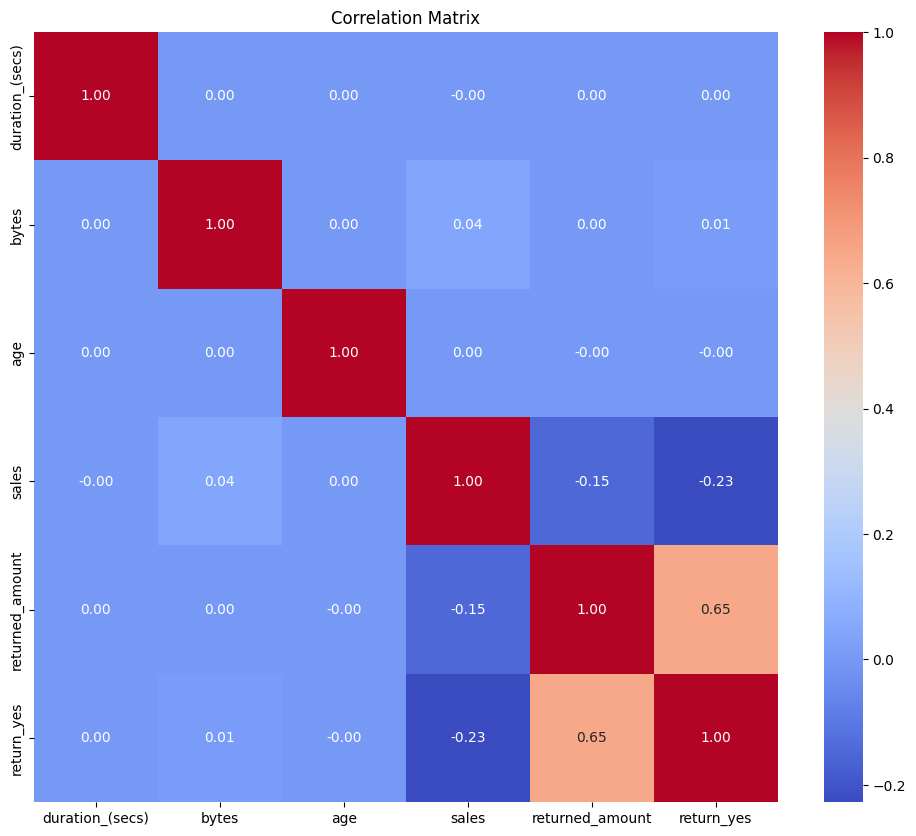

In [7]:

# Copying data to convert logical columns to numbers
df_corr = df.copy()
# Convert true/false columns to 0 and 1
bool_cols = df_corr.select_dtypes(include='bool').columns
df_corr[bool_cols] = df_corr[bool_cols].astype(int)
# Selecting only numerical columns
numeric_df = df_corr.select_dtypes(include=['int64', 'float64'])
# Drawing the correlation matrix
plt.figure(figsize=(12,10))
sns.heatmap(numeric_df.corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

Most variables (such as duration, bytes, age) are completely independent and do not affect sales, while only a significant positive correlation exists between the occurrence of a return and the value of the refund.

This indicates that purchasing and return behavior is not dependent on the technical or demographic characteristics outlined in the matrix.

### Part 1: Analyzing the factors affecting sales

---



### Sales distribution

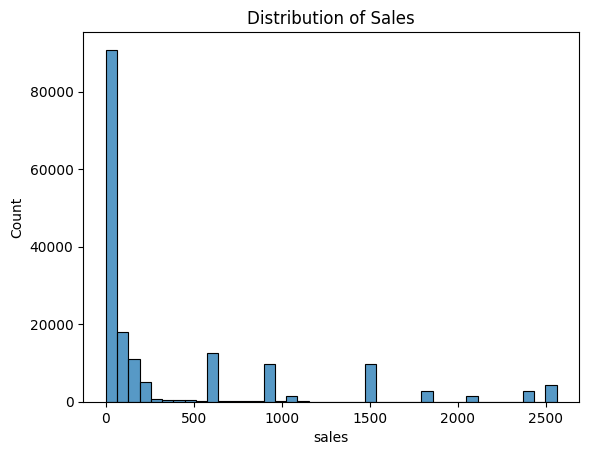

In [8]:
plt.figure()
sns.histplot(df['sales'], bins=40)
plt.title("Distribution of Sales")
plt.show()

#### Key Observations
Sales are primarily based on huge volumes of small transactions, while high-value sales make up very limited exceptions in the overall data.

### Behavioral Factors
#### Analysis by duration_(secs)

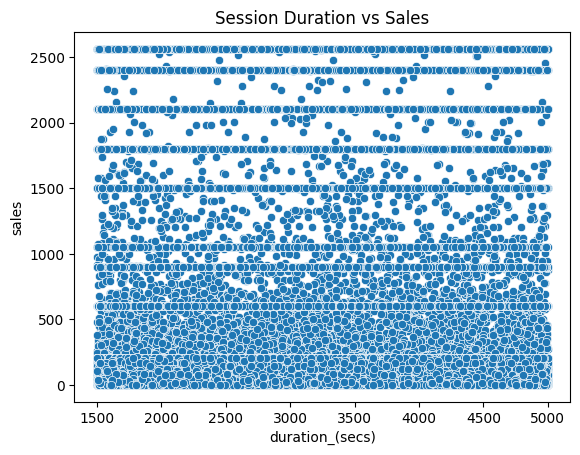

In [9]:
plt.figure()
sns.scatterplot(x='duration_(secs)', y='sales', data=df)
plt.title("Session Duration vs Sales")
plt.show()

#### Key Observations
The data shows no clear trend or correlation between sales record and duration (in seconds).
The data points are highly dense and overlap significantly, especially at the lower end of the sales record scale.
so The data indicates that time is not a factor influencing sales increases or decreases in this case. Sales occur randomly and independently of the time period shown.

### Analysis by membership

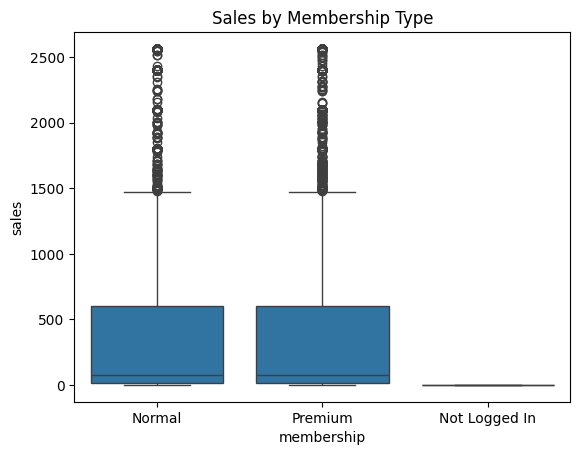

In [10]:
plt.figure()
sns.boxplot(x='membership', y='sales', data=df)
plt.title("Sales by Membership Type")
plt.show()

In [11]:
print(sum(df['membership'] == 'Normal'))
print(sum(df['membership'] == 'Premium'))
print(sum(df['membership'] == 'Not Logged In'))

df['membership'].unique()


49607
107345
15886


<StringArray>
['Normal', 'Premium', 'Not Logged In']
Length: 3, dtype: str

#### Key Observations
Although the Premium membership has the largest number of members (107,345 members), individual spending behavior and sales distribution are exactly the same as for Normal members. There is no substantial difference in median or maximum values ​​between the two categories, indicating that upgrading membership does not necessarily lead to an increase in the value of individual purchase transactions.

### Analysis by age

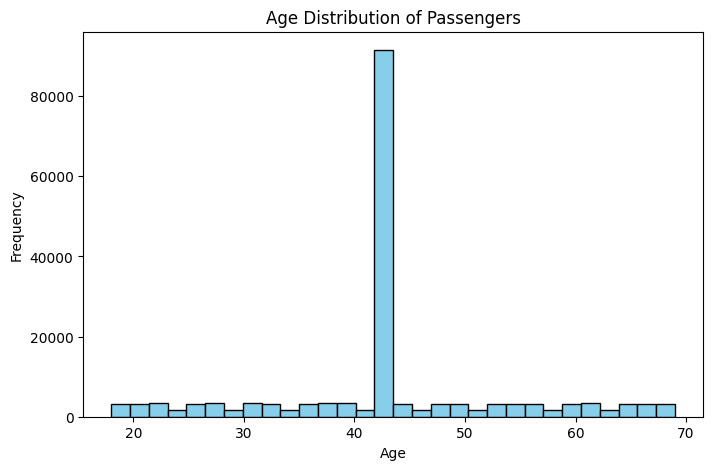

In [12]:
plt.figure(figsize=(8, 5))
plt.hist(df['age'].dropna(), bins=30, color='skyblue', edgecolor='black')
plt.title("Age Distribution of Passengers")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

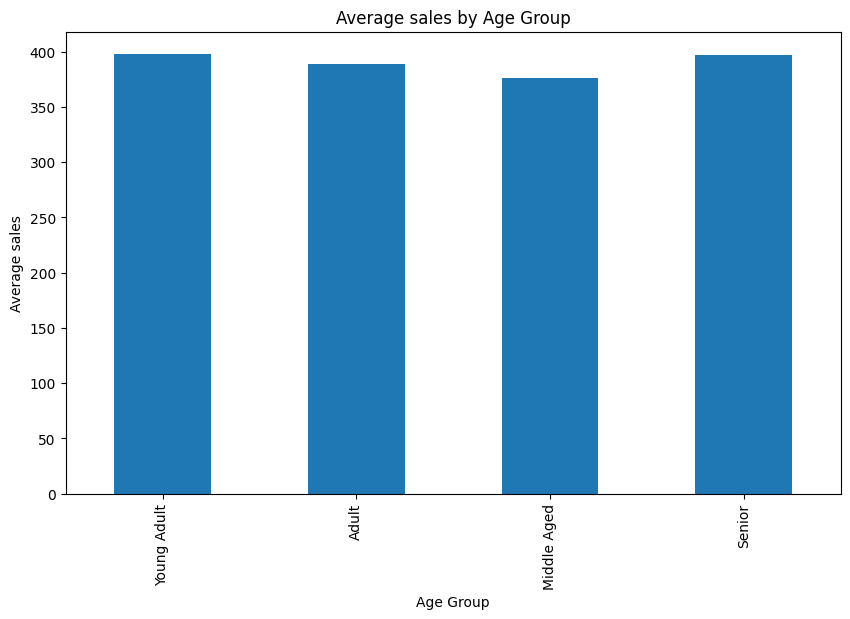

In [13]:
bins = [17, 25, 40, 60, 100]
labels = ['Young Adult', 'Adult', 'Middle Aged', 'Senior']

df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels, right=True)

age_group_return = df.groupby('age_group')['sales'].mean()

plt.figure(figsize=(10, 6))
age_group_return.plot(kind='bar')
plt.title('Average sales by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Average sales')
plt.show()

#### Key Observations
Equal Purchasing Power: We observe that average sales are very similar across all age groups (Young Adult, Adult, Middle Aged, Senior), with the average for all groups ranging from 375 to 400. Age is Insignificant: This graph demonstrates that "customer age" has no real impact on "purchase value." In other words, a young customer spends, on average, the same amount as an elderly customer.

Conforms with Statistics: This result perfectly matches the correlation matrix we analyzed previously, which showed that the correlation between age and sales is close to zero.


### Analysis by gender

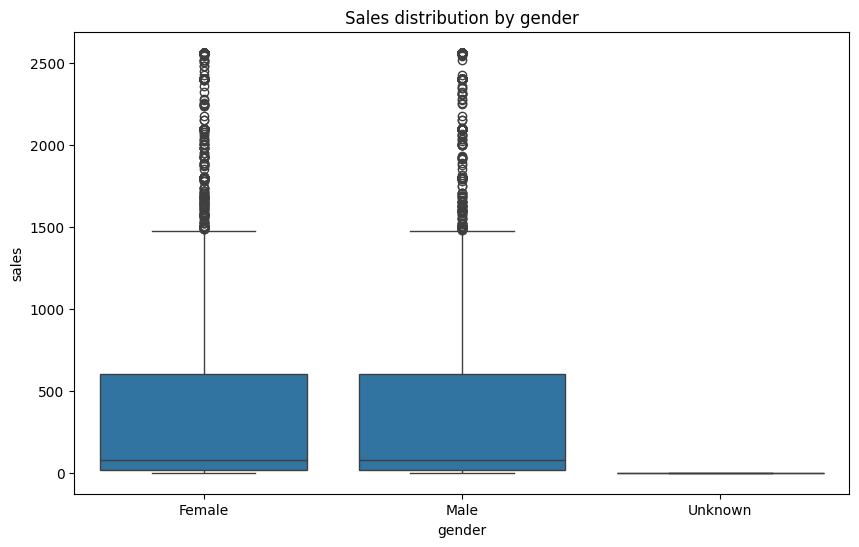

In [14]:
plt.figure(figsize=(10,6))
sns.boxplot(x='gender', y='sales', data=df)

plt.title('Sales distribution by gender')
plt.show()


#### Key Observations
Gender is not a factor in determining sales value at this store. Customers (male or female) tend to spend the same amount of money per transaction.

### Analysis by accessed_From

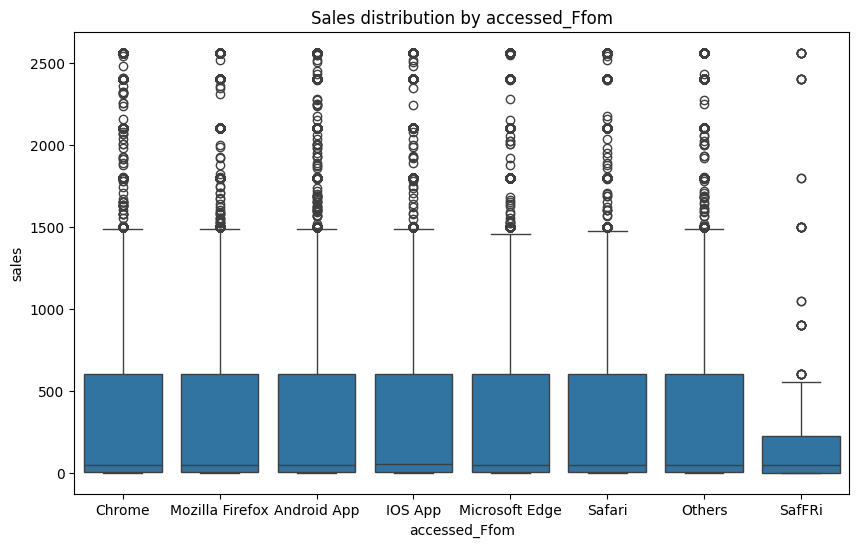

In [15]:
plt.figure(figsize=(10,6))
sns.boxplot(x='accessed_Ffom', y='sales', data=df)
plt.title('Sales distribution by accessed_Ffom')
plt.show()


#### Key Observations
MOST categories showing similar distributions. However, Category SafFRi stands out with lower variability and a lower sales ceiling, suggesting it may represent a lower-performing or limited transaction channel.

### Demographics

### Analysis by contry

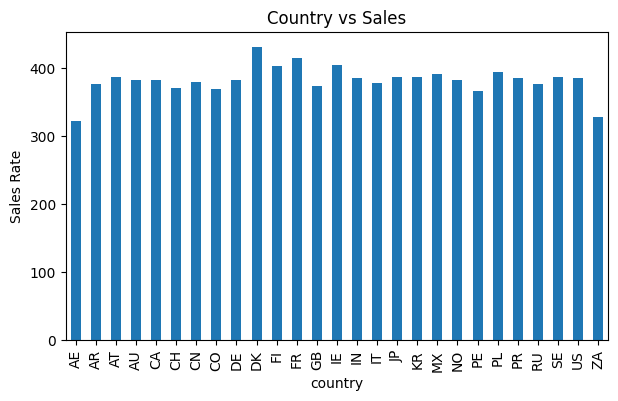

In [16]:
plt.figure(figsize=(7, 4))
df.groupby("country")["sales"].mean().plot(kind="bar")
plt.title("Country vs Sales")
plt.ylabel("Sales Rate")
plt.show()

#### Key Observations
Although there are slight variations favoring some European countries (such as Dk), geography is not a decisive factor in drastically changing sales volume. The company succeeds in maintaining a relatively consistent sales rate globally, which facilitates the implementation of uniform pricing policies.

### Analysis by language

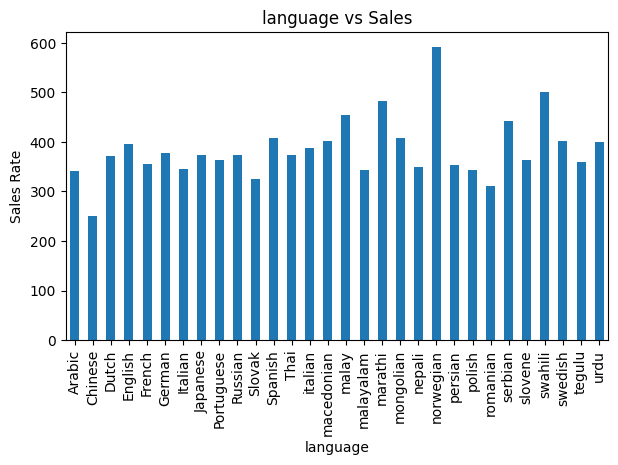

In [17]:
plt.figure(figsize=(7, 4))
df.groupby("language")["sales"].mean().plot(kind="bar")
plt.title("language vs Sales")
plt.ylabel("Sales Rate")
plt.show()

#### Key Observations
Unlike gender and age, we observe a clear disparity in sales rates between different languages.

Top performing languages: Norwegian leads the list with sales rates approaching 600, followed by Swahili with around 500.
Low performing languages: Chinese appears with a very low rate (around 250), followed by Romanian and Slovak.

Popular languages: Languages ​​such as English, French, and German show "average and stable" performance with rates ranging between 350 and 400.


### Temporal Factors

In [18]:
print(df['year'].unique())
print(df['month'].unique())
print(df['day'].unique())
print(df['hour'].unique())


[2017]
[3]
[14 15 16 17 18 19 20 21]
[17 18 19 20  0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 21 22 23]


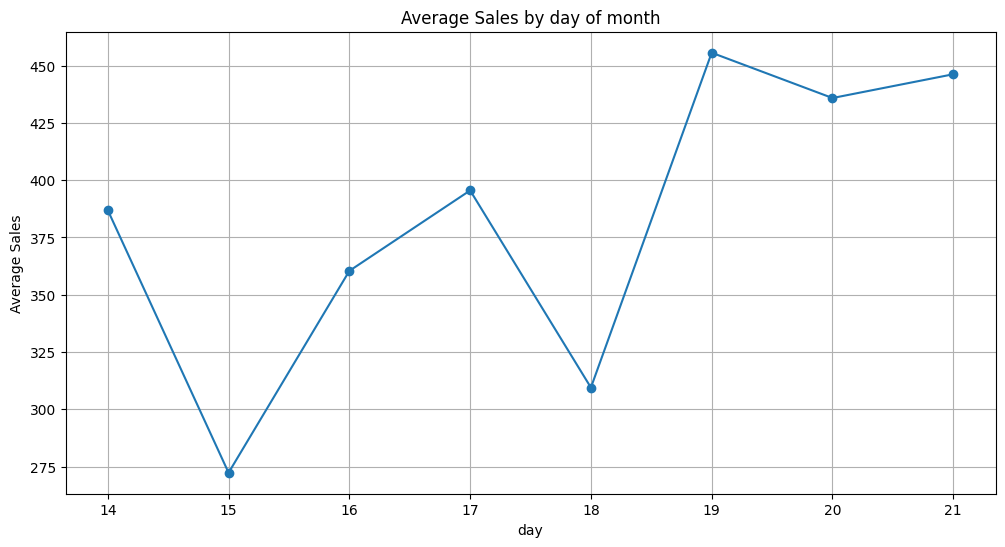

In [19]:
plt.figure(figsize=(12,6))
sales_by_hour = df.groupby('day')['sales'].mean()
sales_by_hour.plot(kind='line', marker='o')
plt.title('Average Sales by day of month')
plt.xlabel('day')
plt.ylabel('Average Sales')
plt.grid(True)
plt.show()

#### Key Observations
Sales showed volatility early on with sharp dips and rises, notably a drop on Day 15 and a surge to a peak on Day 19, followed by consistently high sales through Day 21.

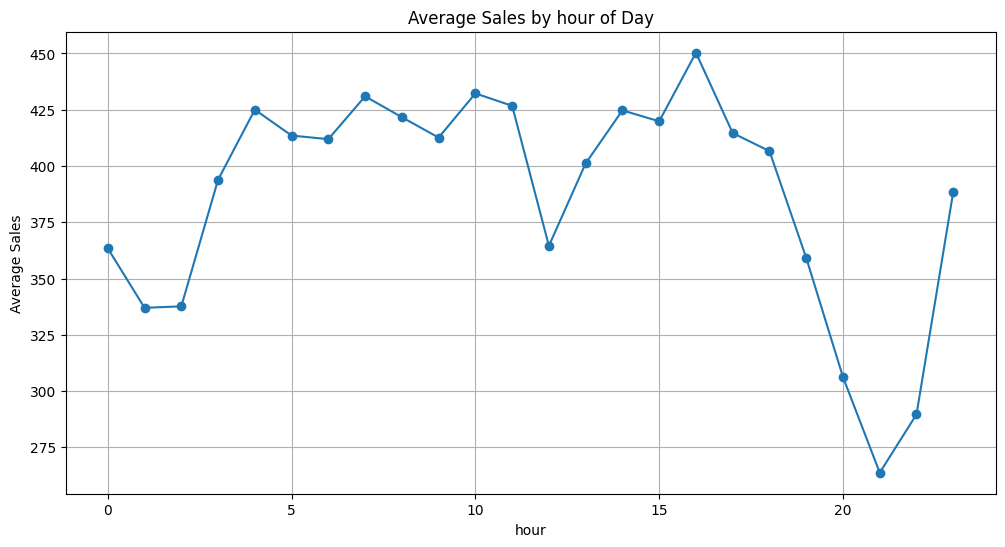

In [20]:
plt.figure(figsize=(12,6))
sales_by_hour = df.groupby('hour')['sales'].mean()
sales_by_hour.plot(kind='line', marker='o')
plt.title('Average Sales by hour of Day')
plt.xlabel('hour')
plt.ylabel('Average Sales')
plt.grid(True)
plt.show()

#### Key Observations
The most profitable period is 4 AM–5 PM, except for a noon dip, while a late-night surge around 10 PM indicates active night shoppers or automated orders.

###  Financial & Transactional

### Analysis by pay_method

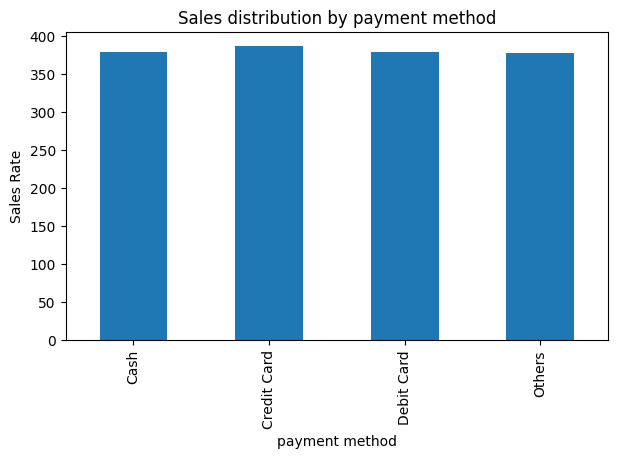

In [21]:
plt.figure(figsize=(7, 4))
df.groupby("pay_method")["sales"].mean().plot(kind="bar")
plt.title('Sales distribution by payment method')
plt.xlabel('payment method')
plt.ylabel("Sales Rate")
plt.show()

#### Key Observations
There is no strong correlation between the payment method and the size of an individual's spending. This means that offering diverse payment options is good for customer convenience and facilitates conversion, but it does not necessarily increase the average value of the shopping basket.


### Analysis by returns

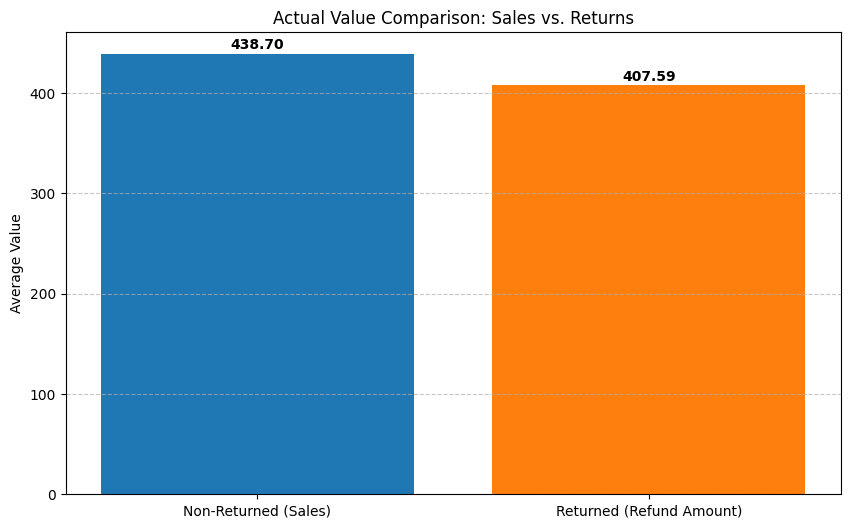

In [ ]:
# 1. Calculate average sales for transactions that were not returned
avg_sales_no = df[df['returned'] == 'No']['sales'].mean()

# 2. Calculate the average refund amount for returned transactions
# Note: We use returned_amount here because sales are often zero for returns
avg_return_yes = df[df['returned'] == 'Yes']['returned_amount'].mean()

# 3. Preparing the data for the drawing
labels = ['Non-Returned (Sales)', 'Returned (Refund Amount)']
values = [avg_sales_no, avg_return_yes]

# 4. Charting the results
plt.figure(figsize=(10, 6))
plt.bar(labels, values, color=['#1f77b4', '#ff7f0e'])

plt.title('Actual Value Comparison: Sales vs. Returns')
plt.ylabel('Average Value')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add values ​​above the columns for clarification
for i, v in enumerate(values):
    plt.text(i, v + 5, f'{v:.2f}', ha='center', fontweight='bold')

plt.show()

#### Key Observations
Each lost return is roughly equivalent to the value of a successful sale. Since the difference is small (around 7%) in favor of successful sales, this suggests that product quality or suitability is the most likely reason for returns, rather than a high price.

### Technical Factors

### Analysis by network_protocol

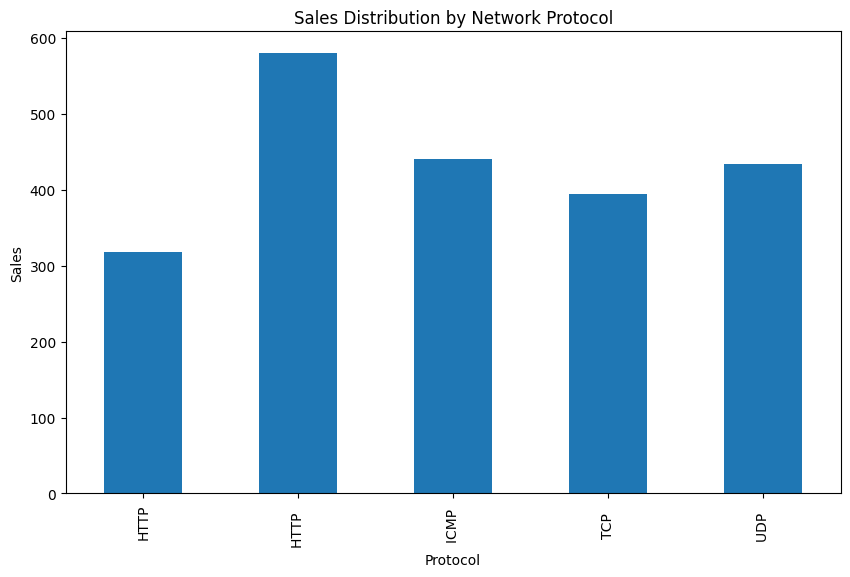

In [23]:
plt.figure(figsize=(10, 6))
df.groupby("network_protocol")["sales"].mean().plot(kind="bar")

plt.title('Sales Distribution by Network Protocol')
plt.xlabel('Protocol')
plt.ylabel('Sales')
plt.show()


#### Key Observations
Sales Analysis by Network Protocol
HTTP Leads: We observe that the highest sales value is achieved via HTTP, with the longest column reaching approximately 580. Technical Note (Data Error): There is duplication of HTTP in two separate columns. This usually indicates extra spacing in the text or a difference in character case (e.g., "http" and "HTTP") in the original data. If we combine the two columns, HTTP will completely dominate the sales.

Other Protocols Convergence: ICMP, TCP, and UDP show very similar performance, with sales values ​​ranging between 400 and 450. Interesting Thing: The presence of sales associated with ICMP (commonly used for ping operations) is unusual in e-commerce data and may indicate that the nature of the products sold is highly technical or network-related.

The type of protocol is a significant factor influencing the sales value shown in this data. The browser or method of ordering (via HTTP) reflects a much higher level of purchasing activity than other communication technologies.

### Part Two: Return Analysis

### Distribution returned_amount

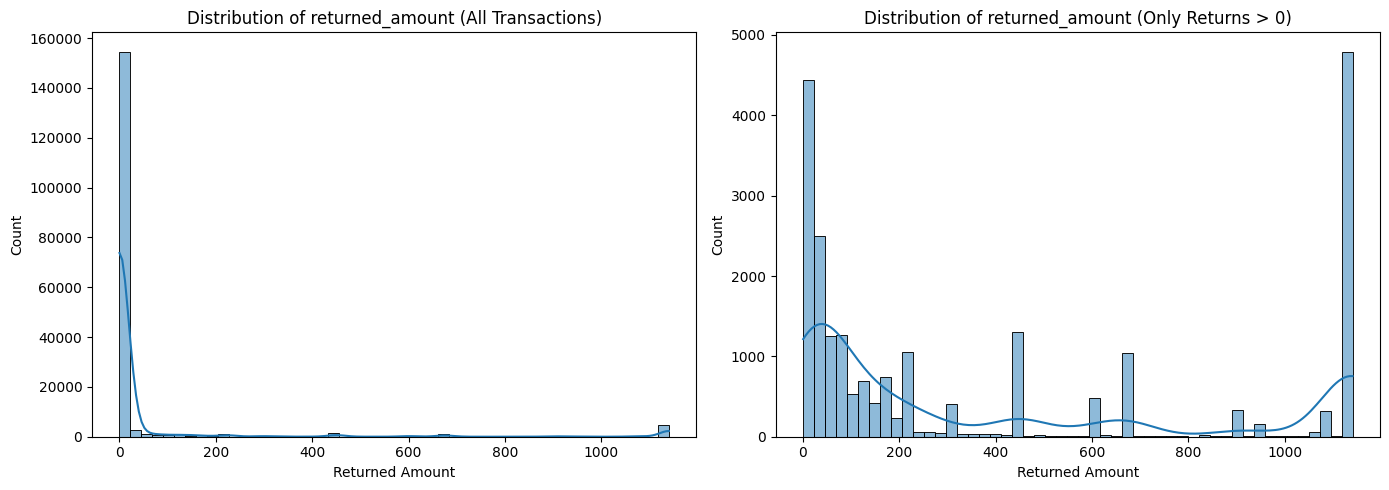

In [24]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
sns.histplot(df['returned_amount'], bins=50, kde=True)
plt.title('Distribution of returned_amount (All Transactions)')
plt.xlabel('Returned Amount')

plt.subplot(1, 2, 2)
returned_non_zero = df[df['returned_amount'] > 0]['returned_amount']
sns.histplot(returned_non_zero, bins=50, kde=True)
plt.title('Distribution of returned_amount (Only Returns > 0)')
plt.xlabel('Returned Amount')

plt.tight_layout()
plt.show()

#### Key Observations
Data Structure (Sparsity): The first graph (left) shows that the vast majority of transactions in the database have a value of 0.0 in the refund column, indicating a low overall return rate compared to total sales volume.

Actual Return Pattern: When we isolate values ​​greater than zero (right graph), we observe a multi-peak distribution, meaning that refunds do not follow a normal, random distribution but are concentrated around specific price points.

Critical Price Spikes:
There is a high density of returns in lower price brackets (below 100).

A very large, sudden peak appears at approximately 1100; this often indicates that a specific product or service at this price point is experiencing a high return rate, necessitating a review of its quality.

#### Which age group has the highest return rate?

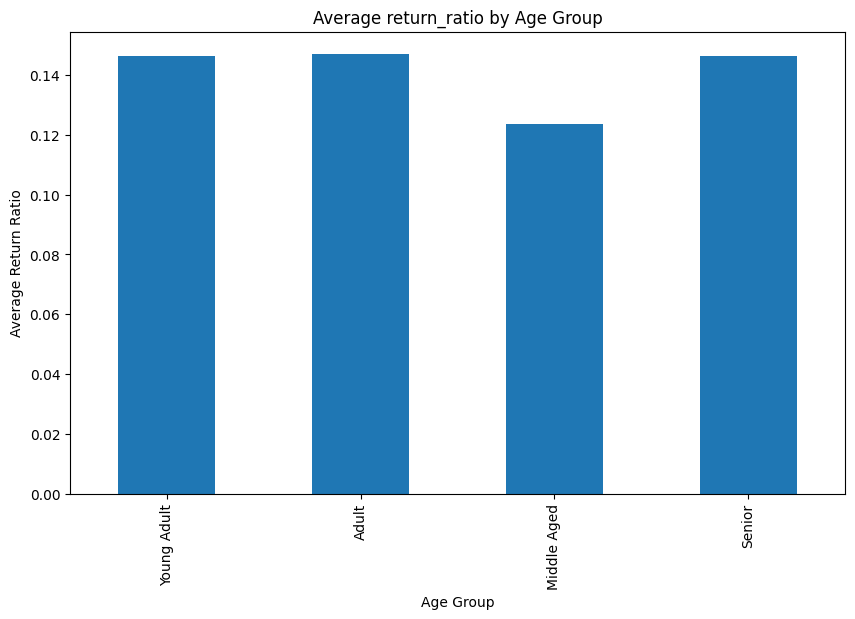

In [35]:
bins = [17, 25, 40, 60, 100]
labels = ['Young Adult', 'Adult', 'Middle Aged', 'Senior']

df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels, right=True)

age_group_return = df.groupby('age_group')['return_yes'].mean()

plt.figure(figsize=(10, 6))
age_group_return.plot(kind='bar')
plt.title('Average return_ratio by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Average Return Ratio')
plt.show()

#### Key Observations
Return Rate Stability: We observe that the Young Adult, Adult, and Senior categories exhibit nearly identical return rates, hovering around 0.145 (or 14.5%).

Most Stable Category (Middle Aged): The Middle Aged category (which includes the 43-year-old age group we previously noted for its high concentration) shows the lowest return rate of all categories, at approximately 0.123 (or 12.3%).

Significant Difference: While the difference may seem small numerically, statistically it means that middle-aged customers are more satisfied with their purchases and less likely to initiate returns compared to younger or older customers.

#### Do clients who have short sessions return more often?

C:\Users\msi\AppData\Local\Temp\ipykernel_8756\1313489239.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='return_yes', y='duration_(secs)', data=df, palette='pastel')


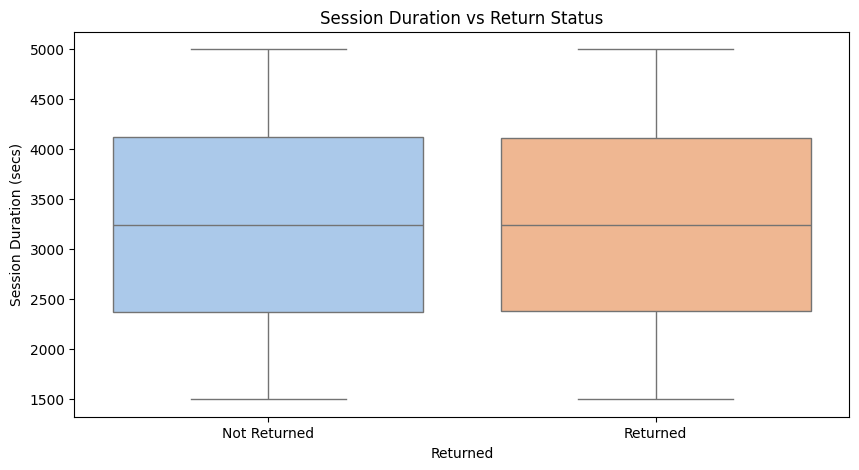

In [26]:

plt.figure(figsize=(10,5))
sns.boxplot(x='return_yes', y='duration_(secs)', data=df, palette='pastel')
plt.xticks([0,1], ['Not Returned','Returned'])
plt.title('Session Duration vs Return Status')
plt.xlabel('Returned')
plt.ylabel('Session Duration (secs)')
plt.show()

#### Key Observations
This graph confirms what was previously shown in the correlation matrix: that "session duration" has no effect on return behavior. We cannot determine whether a customer will return a product simply by observing the time they spend on the site.

#### When a refund occurs, what is its financial pattern?


Correlation between sales and returned_amount: -0.147


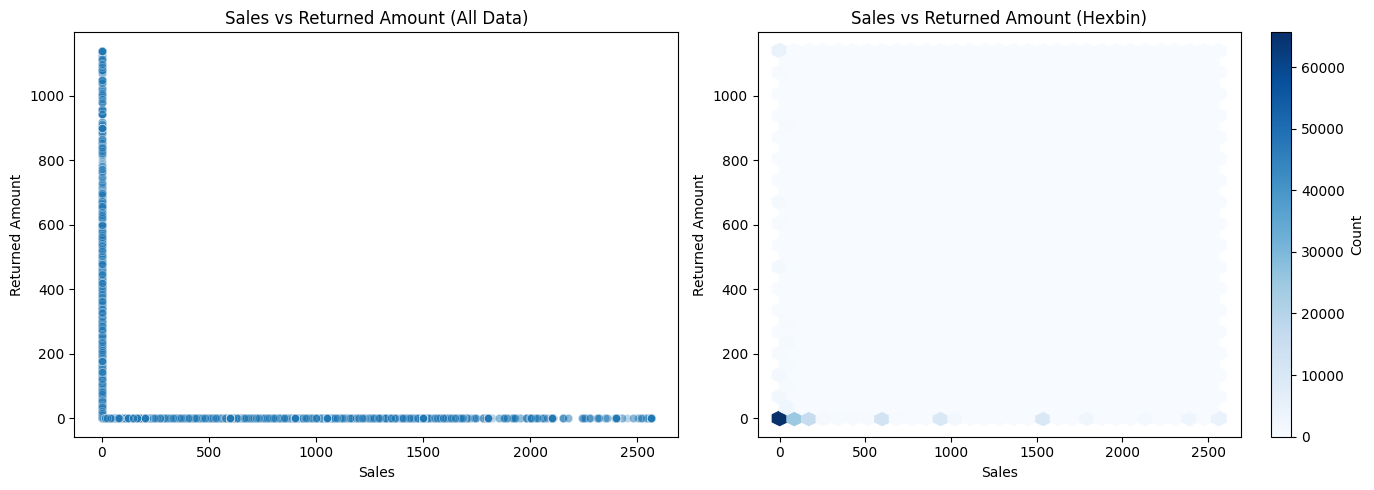


--- Return Ratio Statistics ---
Return ratio stats (all rows):
count    172838.0
mean          0.0
std           0.0
min           0.0
25%           0.0
50%           0.0
75%           0.0
max           0.0
Name: return_ratio, dtype: float64

Return ratio stats (only returned transactions):
count    22564.0
mean         0.0
std          0.0
min          0.0
25%          0.0
50%          0.0
75%          0.0
max          0.0
Name: return_ratio, dtype: float64


In [27]:

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
sns.scatterplot(x='sales', y='returned_amount', data=df, alpha=0.3)
plt.title('Sales vs Returned Amount (All Data)')
plt.xlabel('Sales')
plt.ylabel('Returned Amount')

plt.subplot(1, 2, 2)
correlation = df['sales'].corr(df['returned_amount'])
print(f"\nCorrelation between sales and returned_amount: {correlation:.3f}")

plt.hexbin(x='sales', y='returned_amount', data=df, gridsize=30, cmap='Blues')
plt.title('Sales vs Returned Amount (Hexbin)')
plt.xlabel('Sales')
plt.ylabel('Returned Amount')
plt.colorbar(label='Count')

plt.tight_layout()
plt.show()

df['return_ratio'] = 0.0
mask = df['sales'] > 0
df.loc[mask, 'return_ratio'] = df.loc[mask, 'returned_amount'] / df.loc[mask, 'sales']

print("\n--- Return Ratio Statistics ---")
print("Return ratio stats (all rows):")
print(df['return_ratio'].describe())
print("\nReturn ratio stats (only returned transactions):")
print(df[df['return_yes'] == 1]['return_ratio'].describe())

#### Key Observations
The financial pattern of returns in this data exhibits three main behaviors:

Full Value Shift:
When a return occurs, we observe a "shift" pattern; the sales column is reset to zero (sales = 0), and the entire financial value is transferred to the returned amount column (returned_amount). This is clearly shown in the L-Shape graph, indicating that the return represents a "direct and complete loss" of the sale value.

Value Parity:
The financial ratio per return (407.59) is very close to the sales parity (438.70). This suggests that the financial pattern of returns is not limited to a specific price range (cheap or expensive) but reflects the average product prices in the store as a whole.

Multimodal Spikes:
Returns do not occur in completely random amounts but follow a pattern centered around specific product price points. The most important of these peaks is the financial peak at approximately 1100, which represents the greatest financial pressure on returns, indicating that products with this particular price point are the most influential on the financial pattern of losses resulting from returns.

### Analysis returned_amount by pay_method

C:\Users\msi\AppData\Local\Temp\ipykernel_8756\1299558544.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='pay_method', y='returned_amount', data=df, palette='Set2')


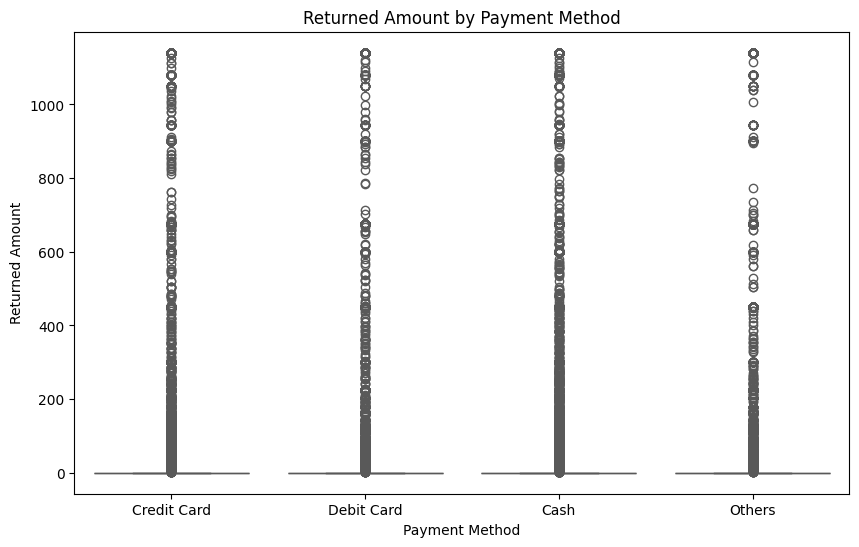

In [28]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='pay_method', y='returned_amount', data=df, palette='Set2')
plt.title('Returned Amount by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Returned Amount')
plt.show()


#### Key Observations
There is no relationship between the payment method and the size of refunds; the financial pattern of returns appears exactly the same in all methods (Cash, Credit, Debit), with the density concentrated in small and medium amounts up to the same price ceiling (about 1150) for all categories.



#### Temporal Factors

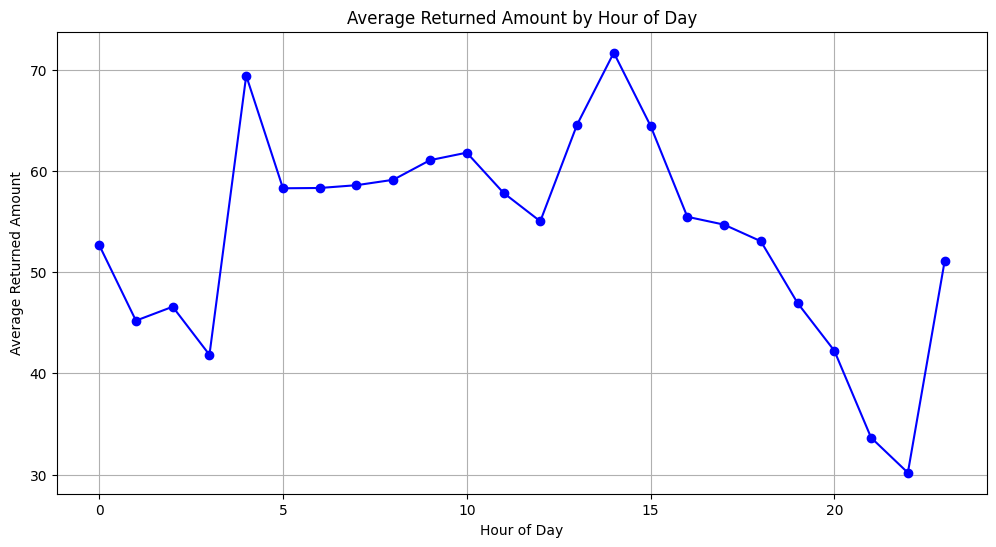

In [29]:
plt.figure(figsize=(12, 6))
returns_by_hour = df.groupby('hour')['returned_amount'].mean()
returns_by_hour.plot(kind='line', marker='o', color='blue')
plt.title('Average Returned Amount by Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Average Returned Amount')
plt.grid(True)
plt.show()


#### Key Observations
Returns reach their peak at 4 am and 2 pm, while their lowest levels are recorded at late evening hours (10 pm).

### Analysis returned by Membership

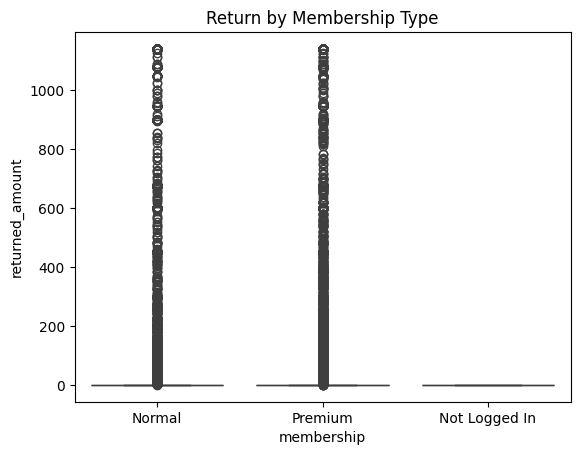

In [30]:
plt.figure()
sns.boxplot(x='membership', y='returned_amount', data=df)
plt.title("Return by Membership Type")
plt.show()

#### Key Observations

The financial pattern of refunds is exactly the same between Normal and Premium memberships; most refunds are concentrated at low values ​​with the same distribution of anomalous values ​​that reach a ceiling of 1150 in both categories.

### Analysis returned by country

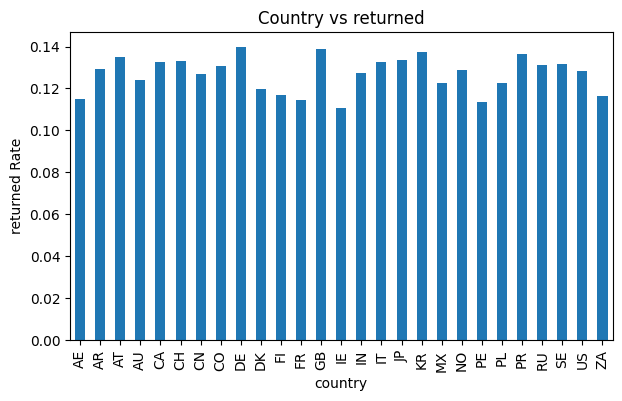

In [31]:
plt.figure(figsize=(7, 4))
df.groupby("country")["return_yes"].mean().plot(kind="bar")
plt.title("Country vs returned")
plt.ylabel("returned Rate")
plt.show()

#### Key Observations
The results show a high degree of stability in the global return rate; the rate in most countries ranges between 12% and 14%, with Germany (DE) and Britain (GB) having the highest return rates, while Ireland (IE) and Peru (PE) have the lowest rates.

### Analysis returned by language

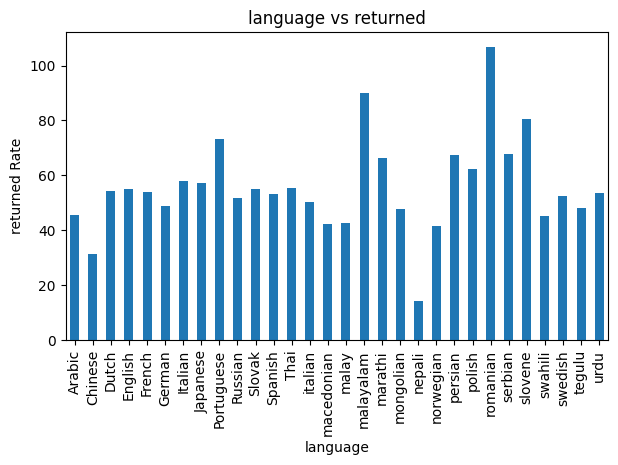

In [32]:
plt.figure(figsize=(7, 4))
df.groupby("language")["returned_amount"].mean().plot(kind="bar")
plt.title("language vs returned")
plt.ylabel("returned Rate")
plt.show()

#### Key Observations

Unlike the previous demographic factors, language shows a very large variation in return rates; Romanian has the highest return rate (over 100), while Nepali has the lowest (less than 20).

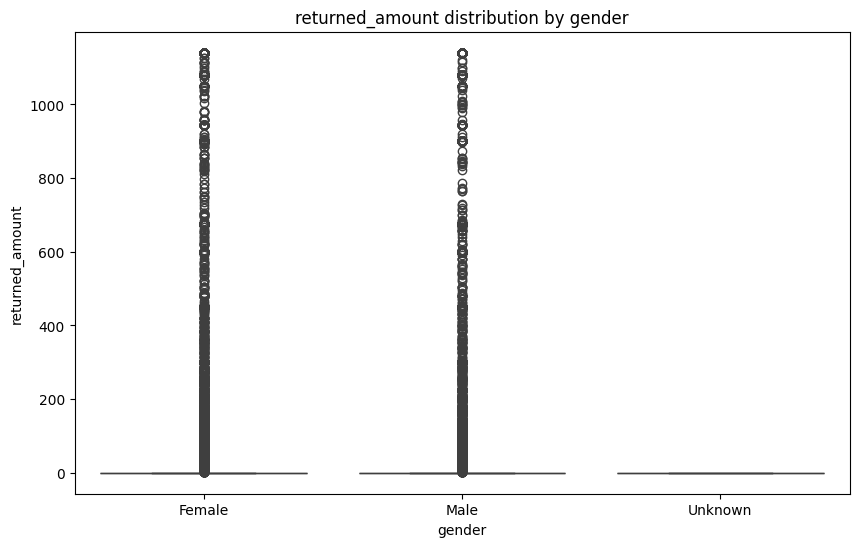

In [33]:
plt.figure(figsize=(10,6))
sns.boxplot(x='gender', y='returned_amount', data=df)

plt.title('returned_amount distribution by gender')
plt.show()


#### Key Observations

The results show a complete match in the financial pattern of returns between genders; the size of the refunded amounts (from 0 to 1150) is distributed with the same intensity among both males and females, while returns are completely absent in the “Unknown” category.

### Final Conclusion

The analysis shows that sales are mainly driven by behavioral factors and membership status rather than demographics or payment methods. Revenue is highly concentrated among a small group of high-value customers, especially Premium members. Temporal patterns also indicate specific days and hours with higher profitability.

Return behavior is mostly associated with extreme price ranges (very low and very high products), while the correlation between sales and refund amounts is weak. A small segment of customers is responsible for a large share of total returns.

Overall, focusing on retaining high-value customers, monitoring high-return users, and optimizing peak sales periods can improve profitability and reduce return-related losses.

It is recommended to improve product descriptions for high-value goods, target marketing campaigns to age groups with high return rates, monitor customers with large returns, review return policies to reduce risks, check technical factors affecting the purchasing experience, and use predictive models to identify high-risk transactions before they occur.